In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the raw meteorological data
weather_path = '../../data/paraguay/meteorological-raw.csv'
df_weather = pd.read_csv(weather_path)

# Display basic info about the weather data
print("Weather data columns:", df_weather.columns.tolist())
print("Data shape:", df_weather.shape)
print("\nFirst few rows:")
print(df_weather.head())

# Identify weather variables (excluding datetime)
weather_vars = ['temperature', 'humidity', 'wind_speed', 'pressure']
print(f"\nWeather variables to analyze: {weather_vars}")

Weather data columns: ['datetime', 'temperature', 'humidity', 'wind_speed', 'pressure']
Data shape: (22445, 5)

First few rows:
              datetime  temperature  humidity  wind_speed  pressure
0  2017-01-01T00:00:00         26.0      85.0         9.3     982.5
1  2017-01-01T03:00:00         25.0      94.0         7.4     981.8
2  2017-01-01T06:00:00         22.0      92.0        14.8     981.3
3  2017-01-01T09:00:00         25.2      90.0        18.5     983.3
4  2017-01-01T12:00:00         28.8      79.0        12.1     985.3

Weather variables to analyze: ['temperature', 'humidity', 'wind_speed', 'pressure']


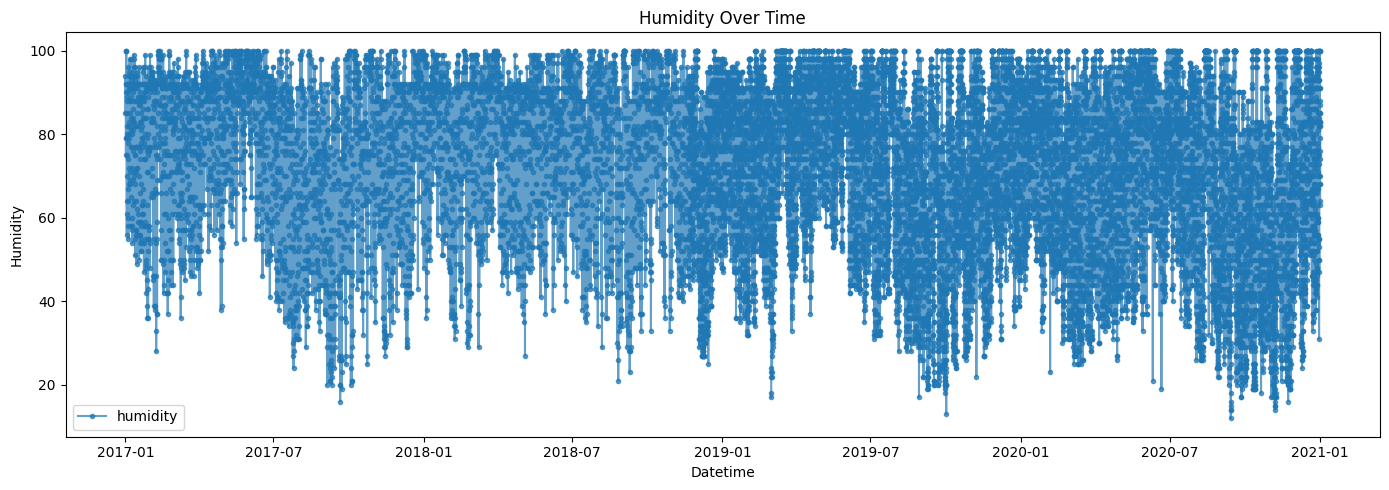

In [21]:
# Plot temperature data over time
weather_var = 'humidity'

plt.figure(figsize=(14, 5))
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])
plt.plot(df_weather['datetime'], df_weather[weather_var], marker='.', linestyle='-', alpha=0.7, label=f'{weather_var}')
plt.xlabel('Datetime')
plt.ylabel(f'{weather_var.capitalize()} (°C)' if weather_var == 'temperature' else weather_var.capitalize())
plt.title(f'{weather_var.capitalize()} Over Time')
plt.legend()
plt.tight_layout()
plt.show()

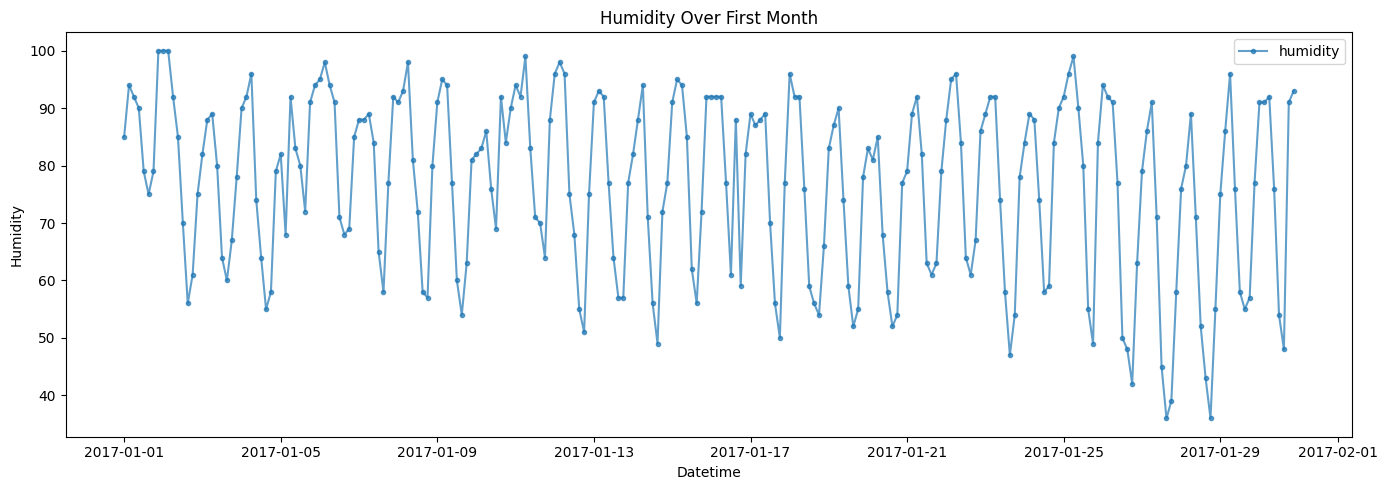

In [22]:
# Plot first month of temperature data

plt.figure(figsize=(14, 5))
df_weather_month = df_weather.copy()[:240]  # First month assuming 3-hourly data (8 per day * 30 days = 240)
df_weather_month['datetime'] = pd.to_datetime(df_weather_month['datetime'])
plt.plot(df_weather_month['datetime'], df_weather_month[weather_var], marker='.', linestyle='-', alpha=0.7, label=weather_var)
plt.xlabel('Datetime')
plt.ylabel(f'{weather_var.capitalize()} (°C)' if weather_var == 'temperature' else weather_var.capitalize())
plt.title(f'{weather_var.capitalize()} Over First Month')
plt.legend()
plt.tight_layout()

# Exploring Outlier Detection Methods for Weather Data

In this section, we will compare several outlier detection methods for meteorological time series data:
- IQR (Interquartile Range)
- Z-score

We will visualize and compare their effectiveness for detecting anomalous weather measurements and discuss the best approach for identifying outliers in temperature, humidity, wind speed, and pressure data.

In [23]:
def rolling_zscore_outliers(df, variable, window_hours, threshold=3):
    """Detect outliers using rolling Z-score for a given weather variable"""
    df = df.copy()
    roll_mean = df[variable].rolling(window_hours, center=True, min_periods=1).mean()
    roll_std = df[variable].rolling(window_hours, center=True, min_periods=1).std()
    z = (df[variable] - roll_mean) / (roll_std + 1e-9)
    return np.abs(z) > threshold

In [24]:
def rolling_iqr_outliers(df, variable, window_hours):
    """Detect outliers using rolling IQR for a given weather variable"""
    df = df.copy()
    roll_Q1 = df[variable].rolling(window_hours, center=True, min_periods=1).quantile(0.25)
    roll_Q3 = df[variable].rolling(window_hours, center=True, min_periods=1).quantile(0.75)
    roll_IQR = roll_Q3 - roll_Q1
    lower = roll_Q1 - 1.5 * roll_IQR
    upper = roll_Q3 + 1.5 * roll_IQR
    return (df[variable] < lower) | (df[variable] > upper)

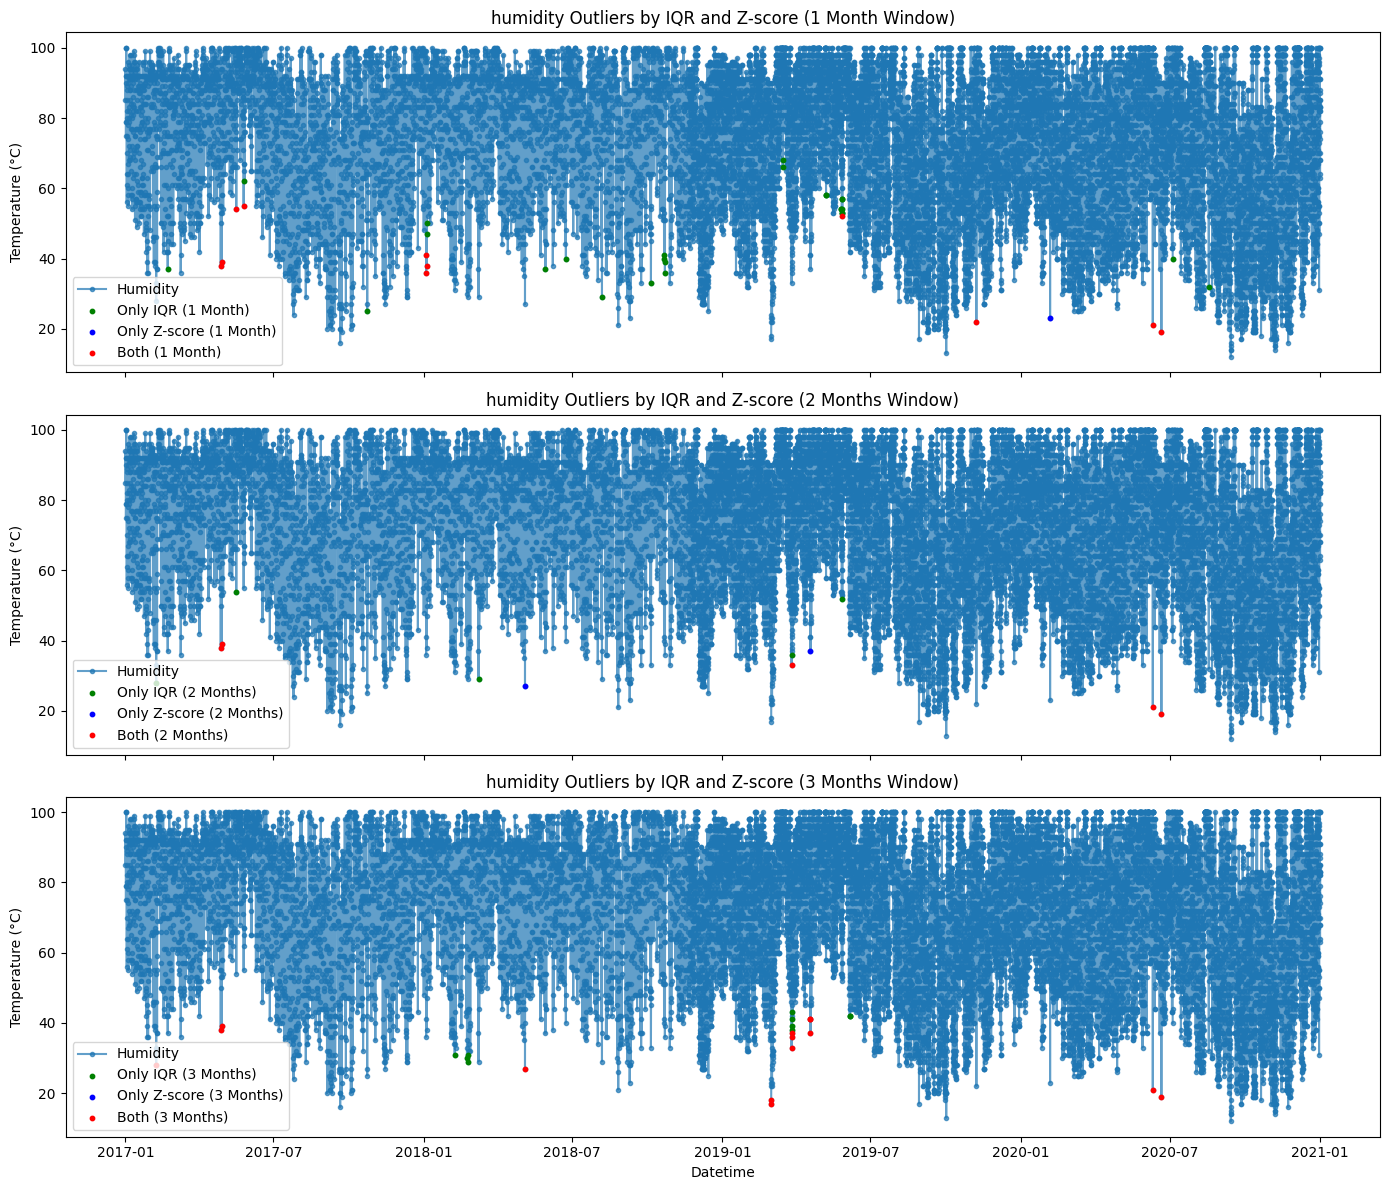

In [31]:
# Z-score and IQR outlier detection comparison for temperature data
# Testing different rolling windows: 1-3 months
windows_months = [30, 60, 90]  # Approximate months as 30 days each (8 measurements per day = 240 per month)
all_windows = windows_months
labels = [f'{m//30} Month' if m == 30 else f'{m//30} Months' for m in windows_months]

fig, axs = plt.subplots(len(all_windows), 1, figsize=(14, 4*len(all_windows)), sharex=True)
if len(all_windows) == 1:
    axs = [axs]

for i, (win, label) in enumerate(zip(all_windows, labels)):
    win_hours = win * 8  # 8 measurements per day (3-hourly data)
    # Calculate outlier masks for this window on temperature
    iqr_mask = rolling_iqr_outliers(df_weather, weather_var, win_hours)
    zscore_mask = rolling_zscore_outliers(df_weather, weather_var, win_hours)
    both_mask = iqr_mask & zscore_mask
    only_iqr_mask = iqr_mask & ~zscore_mask
    only_zscore_mask = zscore_mask & ~iqr_mask

    axs[i].plot(df_weather['datetime'], df_weather[weather_var], marker='.', linestyle='-', alpha=0.7, label=weather_var.title(), zorder=1)

    # Scatter: green = only IQR, blue = only Z-score, red = both
    axs[i].scatter(df_weather.loc[only_iqr_mask, 'datetime'], df_weather.loc[only_iqr_mask, weather_var], color='green', label=f'Only IQR ({label})', zorder=5, s=10)
    axs[i].scatter(df_weather.loc[only_zscore_mask, 'datetime'], df_weather.loc[only_zscore_mask, weather_var], color='blue', label=f'Only Z-score ({label})', zorder=5, s=10)
    axs[i].scatter(df_weather.loc[both_mask, 'datetime'], df_weather.loc[both_mask, weather_var], color='red', label=f'Both ({label})', zorder=5, s=10)

    axs[i].set_title(f'{weather_var} Outliers by IQR and Z-score ({label} Window)')
    axs[i].set_ylabel('Temperature (°C)')
    axs[i].legend()
axs[-1].set_xlabel('Datetime')
plt.tight_layout()
plt.show()

# Testing Z-score Method for Weather Data Outlier Detection

Test z-score method on all weather variables with rolling windows to identify anomalous meteorological measurements.

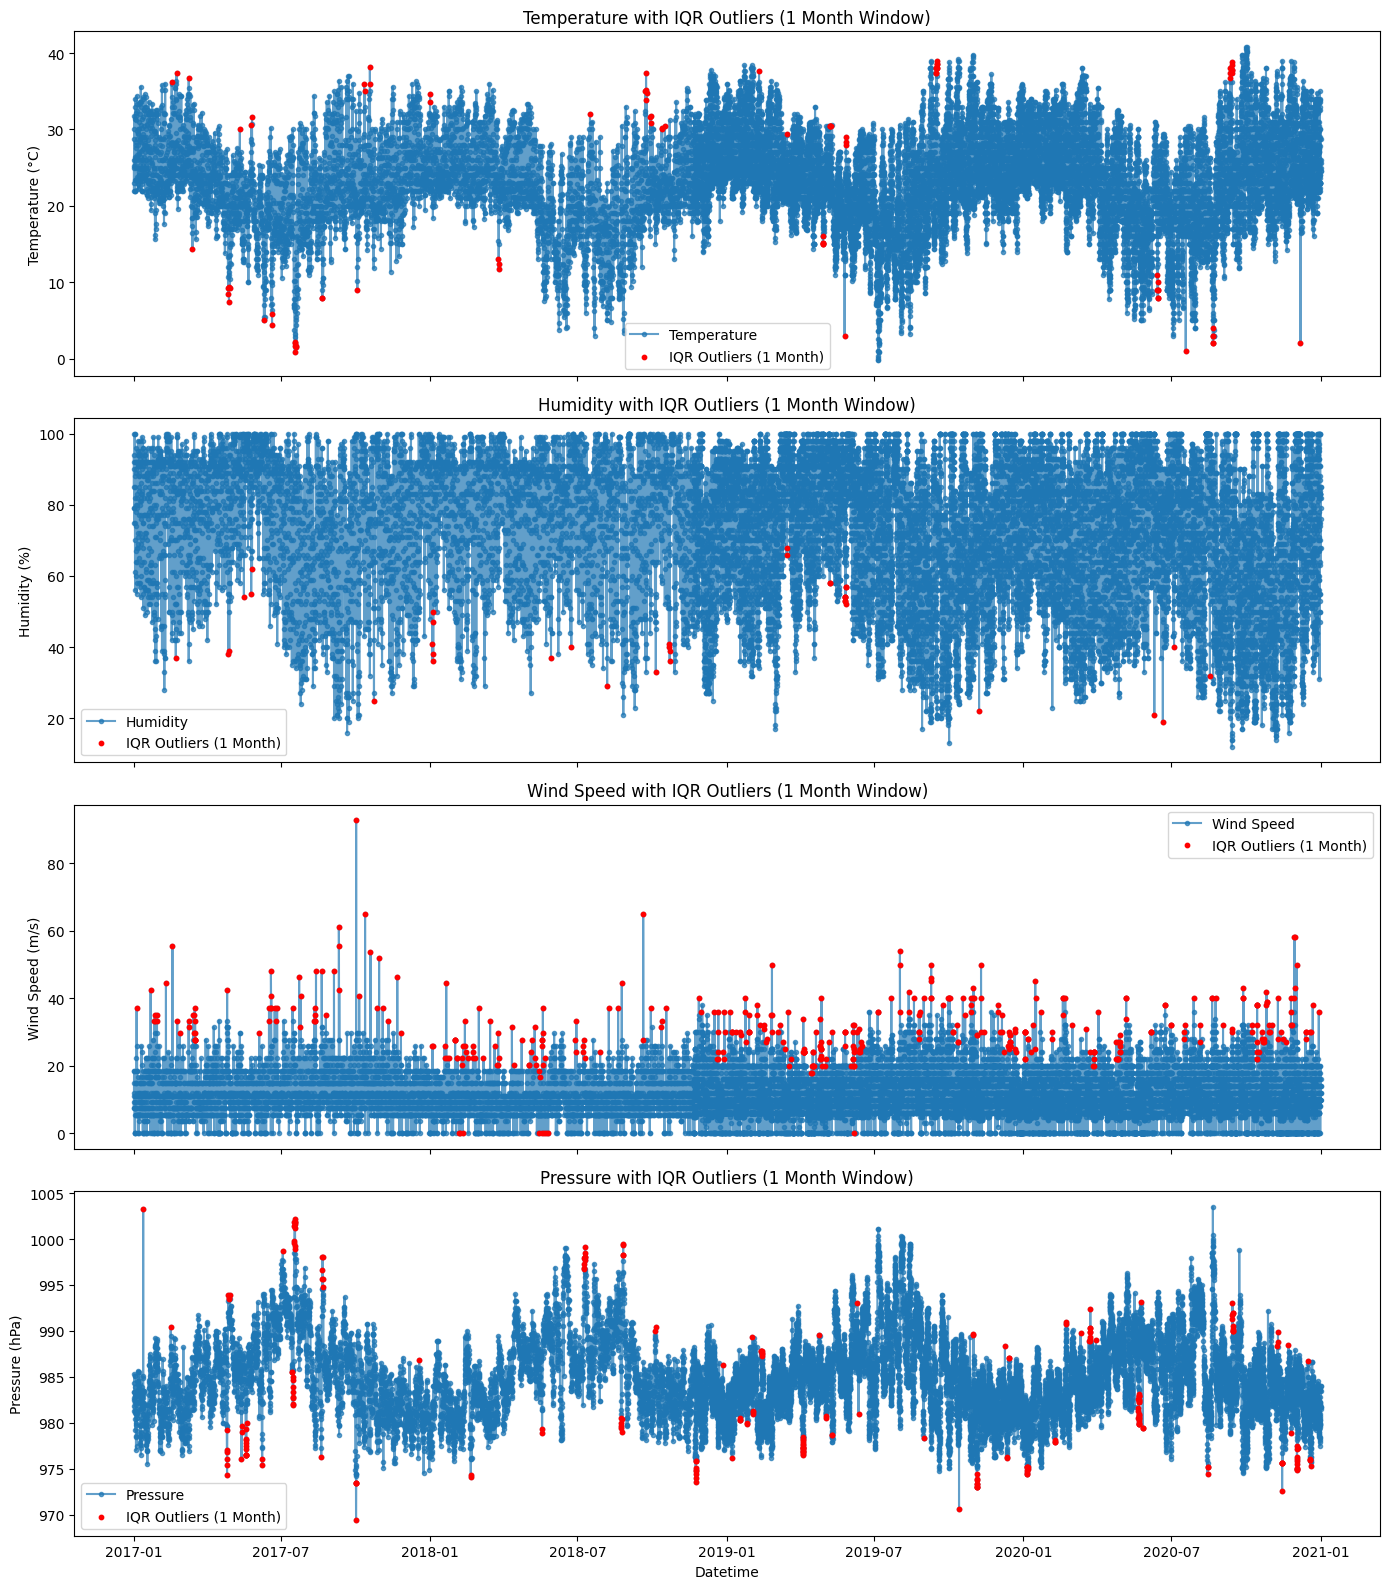

In [34]:
# Plot all weather variables with outliers (Z-score, 1 month window)
weather_variables = ['temperature', 'humidity', 'wind_speed', 'pressure']
window_hours = 30 * 8  # 1 month (8 measurements per day for 30 days)
num_vars = len(weather_variables)

fig, axs = plt.subplots(num_vars, 1, figsize=(14, 4*num_vars), sharex=True)
if num_vars == 1:
    axs = [axs]

units = {'temperature': '°C', 'humidity': '%', 'wind_speed': 'm/s', 'pressure': 'hPa'}

for i, var in enumerate(weather_variables):
    zscore_mask = rolling_iqr_outliers(df_weather, var, window_hours)
    axs[i].plot(df_weather['datetime'], df_weather[var], marker='.', linestyle='-', alpha=0.7, label=f'{var.replace("_", " ").title()}')
    axs[i].scatter(df_weather.loc[zscore_mask, 'datetime'], df_weather.loc[zscore_mask, var], color='red', label='IQR Outliers (1 Month)', zorder=5, s=10)
    axs[i].set_title(f'{var.replace("_", " ").title()} with IQR Outliers (1 Month Window)')
    axs[i].set_ylabel(f'{var.replace("_", " ").title()} ({units.get(var, "")})')
    axs[i].legend()
axs[-1].set_xlabel('Datetime')
plt.tight_layout()
plt.show()

In [36]:
# --- Weather Data Outlier Summary Statistics ---
print("=== Weather Data Outlier Analysis (Z-score, 1 month window) ===\n")

total_points = len(df_weather)
outlier_stats = {}

for var in weather_variables:
    zscore_mask = rolling_iqr_outliers(df_weather, var, window_hours)
    n_outliers = zscore_mask.sum()
    percent = (n_outliers / total_points * 100) if total_points > 0 else 0
    outlier_stats[var] = {'count': n_outliers, 'percent': percent}
    
    print(f"{var.replace('_', ' ').title()}:")
    print(f"  - Total outliers: {n_outliers}")
    print(f"  - Outlier percentage: {percent:.2f}%")
    print()

# Overall summary
total_outliers_all_vars = sum([stats['count'] for stats in outlier_stats.values()])
print(f"Total data points per variable: {total_points}")
print(f"Total datapoints across all variables: {total_points * len(weather_variables)}")
print(f"Total outliers across all variables: {total_outliers_all_vars}")

# Find variable with most/least outliers
if outlier_stats:
    var_most = max(outlier_stats, key=lambda x: outlier_stats[x]['percent'])
    var_least = min(outlier_stats, key=lambda x: outlier_stats[x]['percent'])
    print(f"Variable with most outliers: {var_most.replace('_', ' ').title()} ({outlier_stats[var_most]['percent']:.2f}%)")
    print(f"Variable with least outliers: {var_least.replace('_', ' ').title()} ({outlier_stats[var_least]['percent']:.2f}%)")

=== Weather Data Outlier Analysis (Z-score, 1 month window) ===

Temperature:
  - Total outliers: 91
  - Outlier percentage: 0.41%

Humidity:
  - Total outliers: 37
  - Outlier percentage: 0.16%

Wind Speed:
  - Total outliers: 419
  - Outlier percentage: 1.87%

Pressure:
  - Total outliers: 241
  - Outlier percentage: 1.07%

Total data points per variable: 22445
Total datapoints across all variables: 89780
Total outliers across all variables: 788
Variable with most outliers: Wind Speed (1.87%)
Variable with least outliers: Humidity (0.16%)


C:\Users\knuto\AppData\Local\Temp\ipykernel_53124\945826513.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df_weather_sorted[variable].interpolate().fillna(method='bfill').fillna(method='ffill')


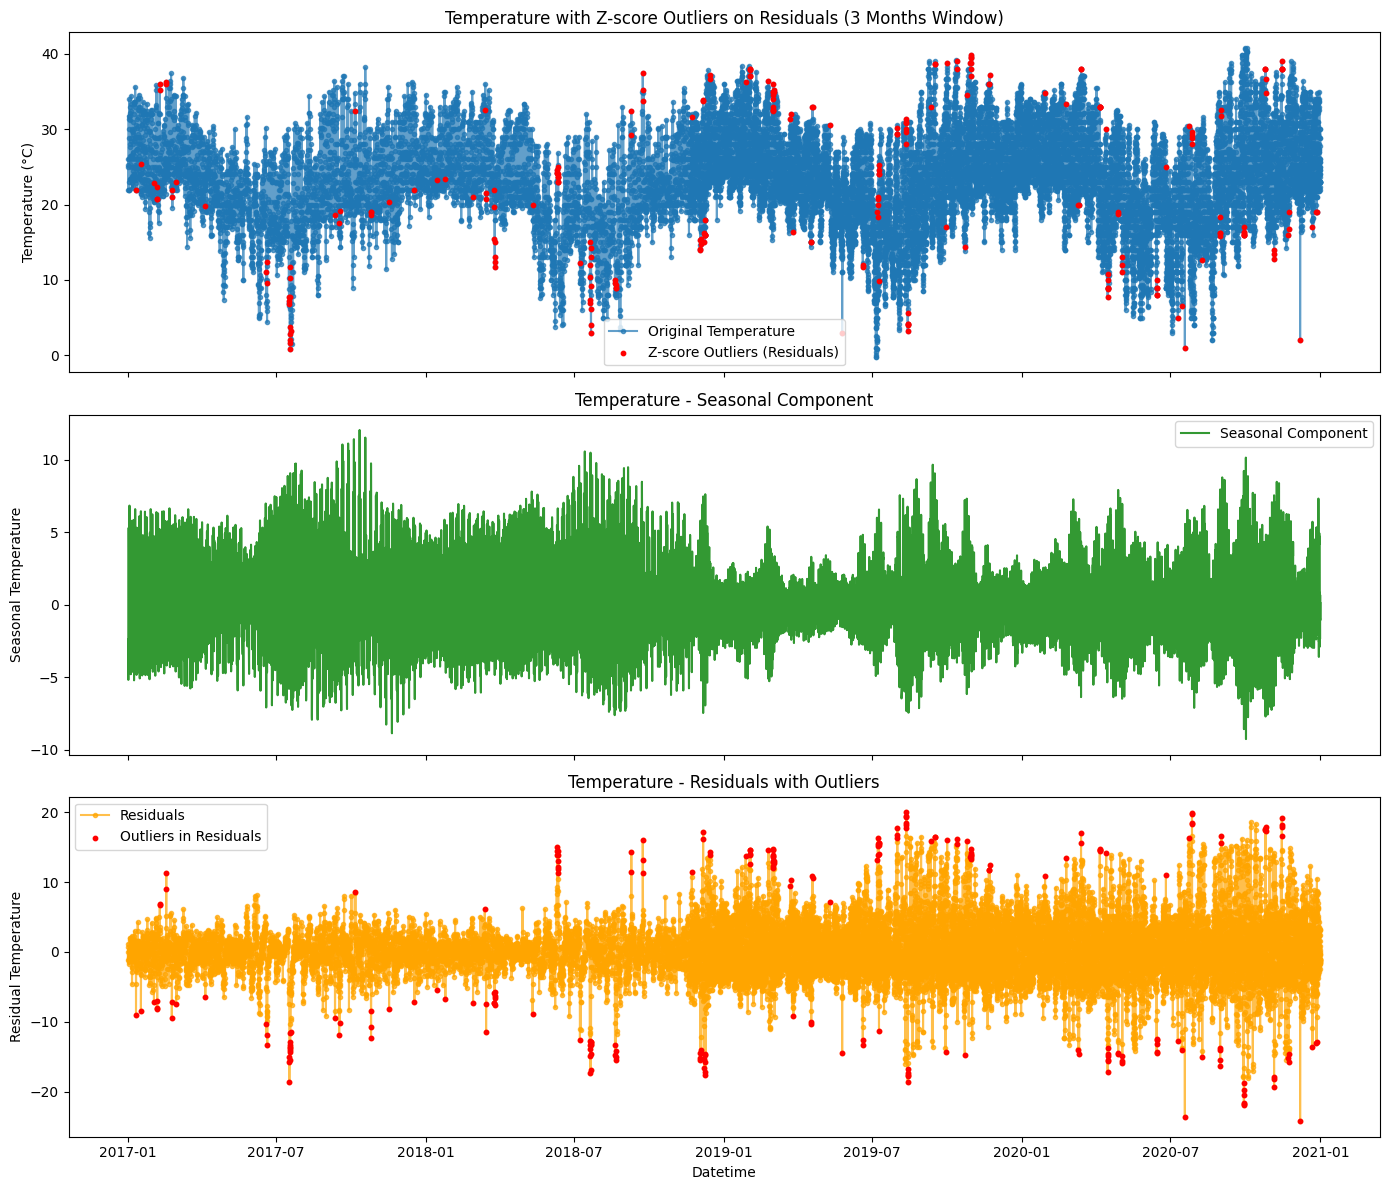


Seasonal decomposition summary for temperature:
Total outliers in residuals: 239
Percentage of outliers in residuals: 1.06%


In [28]:
from statsmodels.tsa.seasonal import STL

# Decompose temperature data and apply Z-score to residuals (seasonal analysis)
variable = 'temperature'  # Focus on temperature for seasonal decomposition
window_hours = 90 * 8  # 3 months (8 measurements per day for 90 days)

# Prepare data for seasonal decomposition
df_weather_sorted = df_weather.copy()
df_weather_sorted['datetime'] = pd.to_datetime(df_weather_sorted['datetime'])
df_weather_sorted = df_weather_sorted.sort_values('datetime')

# Fill missing values for decomposition
y = df_weather_sorted[variable].interpolate().fillna(method='bfill').fillna(method='ffill')

# Perform STL decomposition
# Period = 24*7 / 3 = 56 (weekly pattern in 3-hourly data: 8 measurements per day * 7 days)
stl = STL(y, period=8*7, robust=True)  # Weekly seasonal pattern
res = stl.fit()

# Apply outlier detection to residuals
df_weather_sorted[f'{variable}_residual'] = res.resid
zscore_mask = rolling_zscore_outliers(df_weather_sorted.assign(**{variable: df_weather_sorted[f'{variable}_residual']}), variable, window_hours)

# Plot results
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Original data with outliers
axs[0].plot(df_weather_sorted['datetime'], df_weather_sorted[variable], marker='.', linestyle='-', alpha=0.7, label=f'Original {variable.title()}')
axs[0].scatter(df_weather_sorted.loc[zscore_mask, 'datetime'], df_weather_sorted.loc[zscore_mask, variable], color='red', label='Z-score Outliers (Residuals)', zorder=5, s=10)
axs[0].set_title(f'{variable.title()} with Z-score Outliers on Residuals (3 Months Window)')
axs[0].set_ylabel(f'{variable.title()} ({units.get(variable, "")})')
axs[0].legend()

# Seasonal component
axs[1].plot(df_weather_sorted['datetime'], res.seasonal, color='green', alpha=0.8, label='Seasonal Component')
axs[1].set_title(f'{variable.title()} - Seasonal Component')
axs[1].set_ylabel(f'Seasonal {variable.title()}')
axs[1].legend()

# Residuals with outliers highlighted
axs[2].plot(df_weather_sorted['datetime'], res.resid, marker='.', linestyle='-', alpha=0.7, label='Residuals', color='orange')
axs[2].scatter(df_weather_sorted.loc[zscore_mask, 'datetime'], df_weather_sorted.loc[zscore_mask, f'{variable}_residual'], color='red', label='Outliers in Residuals', zorder=5, s=10)
axs[2].set_title(f'{variable.title()} - Residuals with Outliers')
axs[2].set_ylabel(f'Residual {variable.title()}')
axs[2].set_xlabel('Datetime')
axs[2].legend()

plt.tight_layout()
plt.show()

print(f"\nSeasonal decomposition summary for {variable}:")
print(f"Total outliers in residuals: {zscore_mask.sum()}")
print(f"Percentage of outliers in residuals: {zscore_mask.sum()/len(df_weather_sorted)*100:.2f}%")